# Projeto I EDA — Parte B: Séries temporais de inadimplência no Brasil

**Série principal:** inadimplência da carteira de crédito — pessoas físicas — total, Banco Central do Brasil, SGS 21084.

**Indicadores correlacionados:** Selic acumulada no mês, SGS 4390, e IPCA mensal, SGS 433.

O foco é a evolução histórica da inadimplência, com análise de tendência, médias móveis, correlações contemporâneas e correlações defasadas.


## Introdução

Nesta parte acompanhamos a evolução mensal da inadimplência de pessoas físicas no Brasil. A série principal é a SGS 21084 do Banco Central, que mede o percentual da carteira de crédito com alguma parcela em atraso há mais de 90 dias. É um indicador sensível à saúde financeira das famílias e aos ciclos de crédito e de juros.

Para entender o que acompanha esse movimento, correlacionamos a inadimplência com dois indicadores públicos: a Selic acumulada no mês (SGS 4390), que aproxima o custo do dinheiro, e o IPCA mensal (SGS 433), que aproxima a pressão da inflação sobre o orçamento das famílias. O período coberto começa em março de 2011, primeiro mês em que as três séries estão disponíveis em conjunto.

## Métodos

Coletamos as três séries no Sistema Gerenciador de Séries Temporais (SGS) do Banco Central, padronizamos para frequência mensal e unimos pela data. Sobre essa base, fizemos:

- gráfico da série com média móvel de 12 meses, para separar a tendência das oscilações de curto prazo;
- médias anuais das três séries, para comparar as trajetórias em uma escala mais limpa;
- matriz de correlação, tanto em nível quanto em variação mensal;
- correlações com defasagem de 0 a 12 meses, já que o efeito de juros e inflação sobre o atraso de crédito não é imediato;
- uma regressão linear exploratória com os indicadores defasados.

Tratamos tudo como descritivo. Correlação não é causa: séries macroeconômicas têm tendência, sazonalidade e quebras de regime, e dependem de fatores que não entram aqui, como desemprego, renda, oferta de crédito e renegociações de dívidas.

In [1]:
import sys, subprocess
from pathlib import Path
import os, json, warnings
warnings.filterwarnings("ignore")

# URL deste repositório no GitHub (já configurado).
REPO_URL = "https://github.com/Furlovers/projeto-dc-eda.git"

# No Google Colab, baixamos o projeto (dados + notebooks) direto do GitHub.
# Em execução local, esta etapa é ignorada e usamos a própria pasta do projeto.
IN_COLAB = "google.colab" in sys.modules
COLAB_DIR = Path("/content/projeto_i_eda")
if IN_COLAB and not (COLAB_DIR / "data").exists():
    print("Colab detectado: baixando o projeto do GitHub...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(COLAB_DIR)], check=True)

# Procuramos a raiz do projeto (a pasta que contém data/), seja local ou no Colab.
candidate_roots = [Path.cwd(), Path.cwd().parent, COLAB_DIR, Path("/content")]
ROOT = next((c for c in candidate_roots if (c / "data").exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        "Não encontrei a pasta data/. No Colab, confira o REPO_URL acima e rode esta célula de novo."
    )

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_EXTERNAL = ROOT / "data" / "external"
print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: C:\Users\breno\Projects\faculdade\ciencia-de-dados\projeto_i_eda


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

wide_path = DATA_EXTERNAL / "bcb_inadimplencia_indicadores_wide.csv"
series = pd.read_csv(wide_path, parse_dates=["data"]).sort_values("data")
series = series.set_index("data")

display(series.head())
display(series.tail())
print(series.index.min(), "até", series.index.max(), "| observações:", len(series))


,inadimplencia_pf_total,selic_am,ipca_am,ano,mes,inadimplencia_ma12,selic_ma12,ipca_ma12,inadimplencia_diff,selic_diff,ipca_diff
data,,,,,,,,,,,
2011-03-01,4.62,0.92,0.79,2011,3,NaN,NaN,NaN,NaN,NaN,NaN
2011-04-01,4.67,0.84,0.77,2011,4,NaN,NaN,NaN,0.05,-0.08,-0.02
2011-05-01,4.82,0.99,0.47,2011,5,NaN,NaN,NaN,0.15,0.15,-0.30
2011-06-01,4.79,0.96,0.15,2011,6,NaN,NaN,NaN,-0.03,-0.03,-0.32
2011-07-01,4.90,0.97,0.16,2011,7,NaN,NaN,NaN,0.11,0.01,0.01


,inadimplencia_pf_total,selic_am,ipca_am,ano,mes,inadimplencia_ma12,selic_ma12,ipca_ma12,inadimplencia_diff,selic_diff,ipca_diff
data,,,,,,,,,,,
2025-10-01,4.86,1.28,0.09,2025,10,4.195833,1.076667,0.382500,0.10,0.06,-0.39
2025-11-01,5.00,1.05,0.18,2025,11,4.307500,1.098333,0.365000,0.14,-0.23,0.09
2025-12-01,4.99,1.22,0.33,2025,12,4.428333,1.122500,0.349167,-0.01,0.17,0.15
2026-01-01,5.05,1.16,0.33,2026,1,4.534167,1.135000,0.363333,0.06,-0.06,0.00
2026-02-01,5.24,1.00,0.70,2026,2,4.650000,1.135833,0.312500,0.19,-0.16,0.37


2011-03-01 00:00:00 até 2026-02-01 00:00:00 | observações: 180


In [3]:

# Resumo do nível da inadimplência
resumo = pd.DataFrame({
    "indicador": ["início", "fim", "mínimo", "máximo"],
    "data": [
        series.index[0],
        series.index[-1],
        series["inadimplencia_pf_total"].idxmin(),
        series["inadimplencia_pf_total"].idxmax()
    ],
    "inadimplencia_pf_total": [
        series["inadimplencia_pf_total"].iloc[0],
        series["inadimplencia_pf_total"].iloc[-1],
        series["inadimplencia_pf_total"].min(),
        series["inadimplencia_pf_total"].max()
    ]
})
display(resumo)


,indicador,data,inadimplencia_pf_total
0,início,2011-03-01,4.62
1,fim,2026-02-01,5.24
2,mínimo,2020-12-01,2.84
3,máximo,2012-05-01,5.51


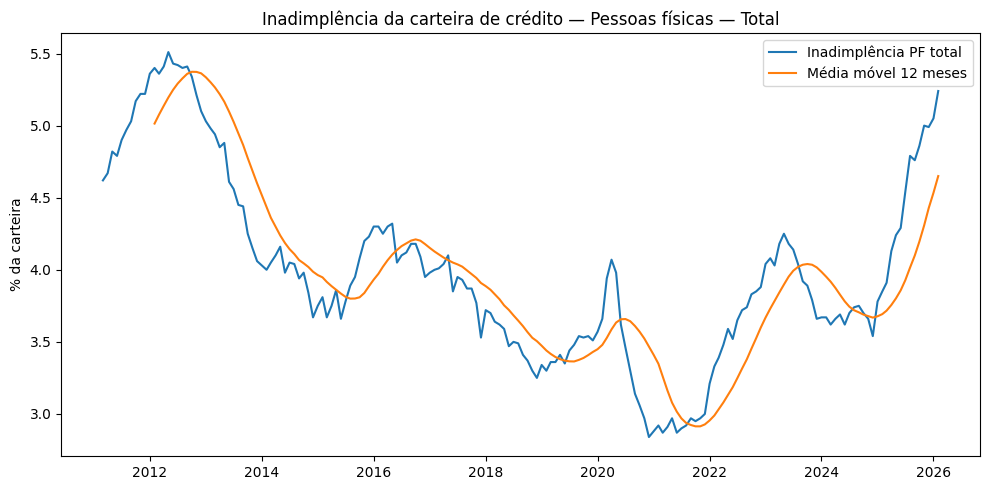

In [4]:

plt.figure(figsize=(10, 5))
plt.plot(series.index, series["inadimplencia_pf_total"], label="Inadimplência PF total")
plt.plot(series.index, series["inadimplencia_ma12"], label="Média móvel 12 meses")
plt.title("Inadimplência da carteira de crédito — Pessoas físicas — Total")
plt.ylabel("% da carteira")
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()


,inadimplencia_pf_total,selic_am,ipca_am
data,,,
2015,3.885833,1.045000,0.849167
2016,4.178333,1.100000,0.510000
2017,3.908333,0.794167,0.242500
2018,3.505000,0.520000,0.307500
2019,3.430000,0.482500,0.352500
2020,3.467500,0.226667,0.370000
2021,2.927500,0.362500,0.802500
2022,3.599167,0.977500,0.471667
2023,4.016667,1.025833,0.377500


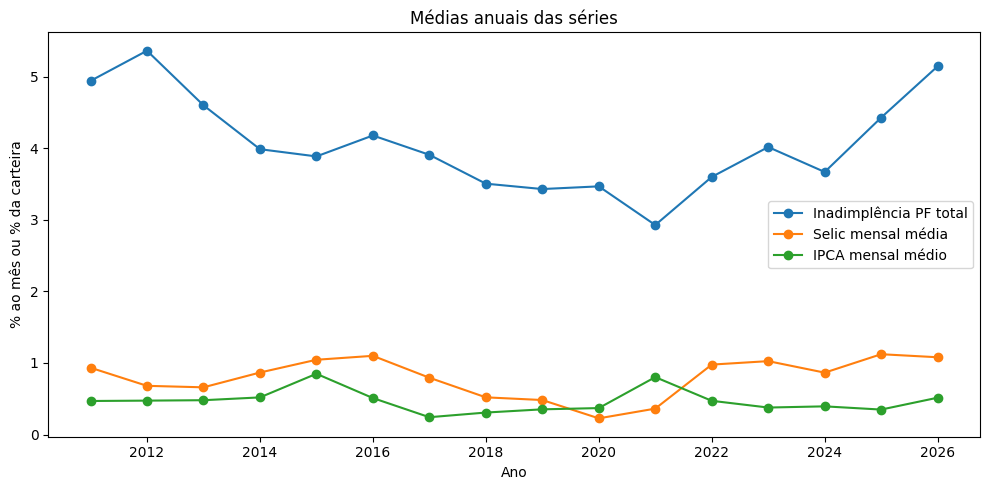

In [5]:

anuais = series.groupby(series.index.year)[["inadimplencia_pf_total", "selic_am", "ipca_am"]].mean()
display(anuais.tail(12))

plt.figure(figsize=(10, 5))
plt.plot(anuais.index, anuais["inadimplencia_pf_total"], marker="o", label="Inadimplência PF total")
plt.plot(anuais.index, anuais["selic_am"], marker="o", label="Selic mensal média")
plt.plot(anuais.index, anuais["ipca_am"], marker="o", label="IPCA mensal médio")
plt.title("Médias anuais das séries")
plt.ylabel("% ao mês ou % da carteira")
plt.xlabel("Ano")
plt.legend()
plt.tight_layout()
plt.show()


## Correlações contemporâneas

,inadimplencia_pf_total,selic_am,ipca_am
inadimplencia_pf_total,1.000000,0.412161,-0.143085
selic_am,0.412161,1.000000,-0.053325
ipca_am,-0.143085,-0.053325,1.000000


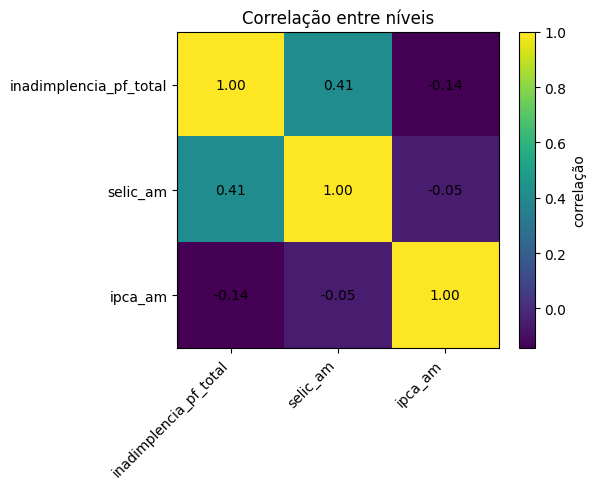

,inadimplencia_diff,selic_diff,ipca_diff
inadimplencia_diff,1.000000,-0.004750,-0.137945
selic_diff,-0.004750,1.000000,-0.052399
ipca_diff,-0.137945,-0.052399,1.000000


In [6]:

cols_niveis = ["inadimplencia_pf_total", "selic_am", "ipca_am"]
corr_niveis = series[cols_niveis].corr()
display(corr_niveis)

plt.figure(figsize=(6, 5))
plt.imshow(corr_niveis, aspect="auto")
plt.colorbar(label="correlação")
plt.xticks(range(len(cols_niveis)), cols_niveis, rotation=45, ha="right")
plt.yticks(range(len(cols_niveis)), cols_niveis)
plt.title("Correlação entre níveis")
for i in range(len(cols_niveis)):
    for j in range(len(cols_niveis)):
        plt.text(j, i, f"{corr_niveis.iloc[i,j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

cols_diff = ["inadimplencia_diff", "selic_diff", "ipca_diff"]
corr_diff = series[cols_diff].dropna().corr()
display(corr_diff)


## Correlações com defasagens

A inadimplência pode reagir a juros e inflação com atraso. Por isso, calculamos a correlação da inadimplência no mês *t* com Selic/IPCA defasados de 0 a 12 meses.

,indicador,lag_meses,corr_nivel,corr_variacao
0,selic_am,0,0.412161,-0.004750
1,selic_am,1,0.449163,0.110177
2,selic_am,2,0.476504,0.178701
3,selic_am,3,0.493890,-0.101738
4,selic_am,4,0.521037,0.210949
5,selic_am,5,0.532671,0.073809
6,selic_am,6,0.542277,0.012092
7,selic_am,7,0.553059,0.176555
8,selic_am,8,0.552808,0.080274
9,selic_am,9,0.552990,0.112621


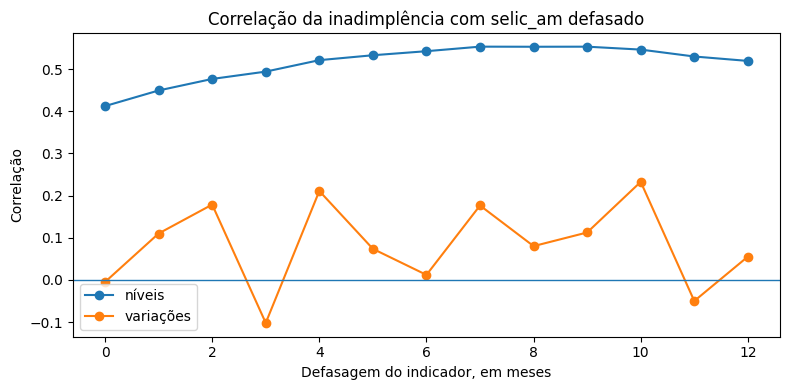

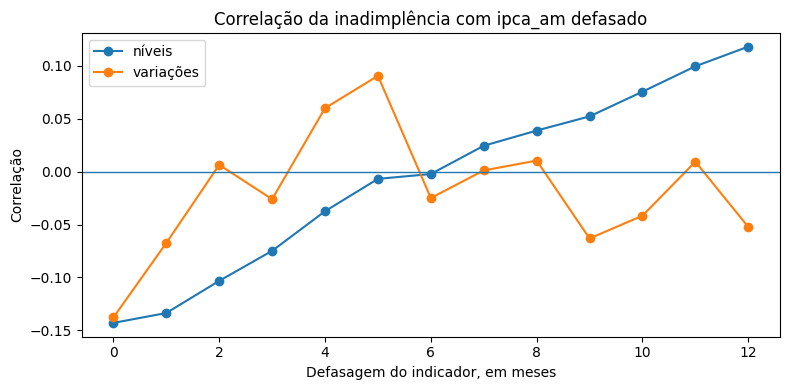

In [7]:

lag_rows = []
for indicador in ["selic_am", "ipca_am"]:
    for lag in range(13):
        lag_rows.append({
            "indicador": indicador,
            "lag_meses": lag,
            "corr_nivel": series["inadimplencia_pf_total"].corr(series[indicador].shift(lag)),
            "corr_variacao": series["inadimplencia_diff"].corr(series[indicador].diff().shift(lag))
        })
lags = pd.DataFrame(lag_rows)
display(lags)

for indicador in ["selic_am", "ipca_am"]:
    sub = lags[lags["indicador"] == indicador]
    plt.figure(figsize=(8, 4))
    plt.plot(sub["lag_meses"], sub["corr_nivel"], marker="o", label="níveis")
    plt.plot(sub["lag_meses"], sub["corr_variacao"], marker="o", label="variações")
    plt.title(f"Correlação da inadimplência com {indicador} defasado")
    plt.xlabel("Defasagem do indicador, em meses")
    plt.ylabel("Correlação")
    plt.axhline(0, linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Regressão exploratória

A regressão abaixo não busca inferência causal. Ela apenas resume, em um modelo simples, a associação entre inadimplência e indicadores defasados escolhidos a partir da análise de correlação. Em um estudo causal, seria necessário controlar por renda, emprego, expansão de crédito, renegociações, composição da carteira e quebras de regime.

In [8]:

try:
    import statsmodels.api as sm

    model_df = series.copy()
    model_df["selic_lag7"] = model_df["selic_am"].shift(7)
    model_df["ipca_lag12"] = model_df["ipca_am"].shift(12)
    model_df = model_df.dropna(subset=["inadimplencia_pf_total", "selic_lag7", "ipca_lag12"])

    y = model_df["inadimplencia_pf_total"]
    X = sm.add_constant(model_df[["selic_lag7", "ipca_lag12"]])
    modelo = sm.OLS(y, X).fit()

    print(modelo.summary())
except Exception as e:
    print("Não foi possível estimar o modelo OLS neste ambiente:", e)


                              OLS Regression Results                              
Dep. Variable:     inadimplencia_pf_total   R-squared:                       0.308
Model:                                OLS   Adj. R-squared:                  0.300
Method:                     Least Squares   F-statistic:                     36.78
Date:                    Sun, 07 Jun 2026   Prob (F-statistic):           6.17e-14
Time:                            11:55:18   Log-Likelihood:                -124.11
No. Observations:                     168   AIC:                             254.2
Df Residuals:                         165   BIC:                             263.6
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

## Discussão dos resultados

A série vai de 4,62% em março de 2011 a 5,24% em fevereiro de 2026, com mínimo de 2,84% em dezembro de 2020 (auge da pandemia, com juros baixos e crédito reorganizado) e máximo de 5,51% em maio de 2012. A partir de 2022 ela se desloca para um patamar mais alto, acompanhando o ciclo de Selic elevada.

Nas correlações em nível, a inadimplência anda junto com a Selic (0,41) e tem relação fraca e negativa com o IPCA (-0,14). Em variação mensal as correlações encolhem, o que reforça a cautela. O resultado mais interessante aparece nas defasagens: a Selic de 7 meses atrás se correlaciona 0,55 com a inadimplência de hoje, mais do que a Selic do mês corrente. Isso é coerente com o funcionamento do crédito, em que o aperto de juros leva meses para virar atraso acima de 90 dias. Para o IPCA, mesmo a melhor defasagem (12 meses) fica baixa, em 0,12.

A regressão exploratória resume esse quadro: com a Selic defasada em 7 meses e o IPCA em 12, o modelo explica cerca de 31% da variância (R² = 0,308); a Selic defasada é fortemente significativa (p < 0,001) e o IPCA não (p = 0,72). Vale registrar uma limitação: o Durbin-Watson de 0,07 indica forte autocorrelação dos resíduos, esperada em séries em nível, o que reforça que o modelo é apenas descritivo e não serve para inferência causal.

## Conclusão

A inadimplência de pessoas físicas não se move sozinha nem reage a choques de um mês para o outro: ela tem ciclos longos e responde, com defasagem, às condições de juros. Entre os dois indicadores, a Selic é o que mostra associação mais clara; o IPCA, isolado, diz pouco. O passo seguinte natural seria incorporar desemprego, massa de rendimentos, comprometimento de renda das famílias, saldo da carteira de crédito e renegociações, para testar explicações mais completas do que a leitura apenas por juros e inflação.